# Test Amplitude Compensation for Universal GASP

This notebook validates the T2/T1 estimation and amplitude compensation approach.

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')

from gasp.ssfp import ssfp
from gasp.gasp import train_gasp, run_gasp
from gasp import responses
from gasp.simulation import SSFPParams, simulate_ssfp_simple
from gasp.compensated import (
    estimate_t2_from_tr_decay,
    estimate_t1_from_profile,
    estimate_t1_t2_planet,
    normalize_signals,
    train_compensated_gasp,
    run_compensated_gasp,
)

# Acquisition parameters (matching gasp_analysis.ipynb)
TRs = [5e-3, 10e-3, 15e-3]
alpha = np.deg2rad(60)  # 60 degrees as in analysis notebook
npcs = 8  # Match analysis notebook
pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)

# Image dimensions
WIDTH = 256   # Spectral dimension (frequency samples)
HEIGHT = 1    # Spatial dimension

# Build SSFPParams for simulation (matches gasp_analysis.ipynb pattern)
n_acq = npcs * len(TRs)
alpha_list = [alpha] * n_acq
TR_list = []
pc_list = []
for tr in TRs:
    for pc in pcs:
        TR_list.append(tr)
        pc_list.append(pc)

PARAMS = SSFPParams(n_acq, alpha_list, TR_list, pc_list)
MIN_TR = TRs[0]

def simulate_tissue(T1, T2, width=WIDTH, height=HEIGHT):
    """Simulate bSSFP for a tissue type using SSFPParams (matching analysis notebook)."""
    M = simulate_ssfp_simple(
        width=width, height=height,
        T1=T1, T2=T2,
        params=PARAMS,
        minTR=MIN_TR
    )
    return M

def simulate_multi_tr(T1, T2, TRs, alpha, pcs, M0=1.0):
    """Simulate multi-TR phase-cycled bSSFP signal for a single voxel (on-resonance)."""
    signals = []
    for TR in TRs:
        TE = TR / 2
        sig = ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)
        signals.append(sig)
    return np.concatenate(signals, axis=-1)

def simulate_single_tr(T1, T2, TR, alpha, pcs, M0=1.0):
    """Simulate phase-cycled bSSFP for single TR (for PLANET)."""
    TE = TR / 2
    return ssfp(T1, T2, TR, TE, alpha, dphi=pcs, M0=M0)

print(f"Simulation parameters:")
print(f"  TRs: {[tr*1000 for tr in TRs]} ms")
print(f"  Flip angle: {np.rad2deg(alpha):.0f} degrees")
print(f"  Phase cycles: {npcs}")
print(f"  Total acquisitions: {n_acq}")

Simulation parameters:
  TRs: [5.0, 10.0, 15.0] ms
  Flip angle: 60 degrees
  Phase cycles: 8
  Total acquisitions: 24


## Test T1/T2 Estimation using PLANET

PLANET (Phase-cycLed bSSFP ANalytical T2/T1 Estimation) exploits the elliptical property of phase-cycled bSSFP signals:

- In the complex plane, signals at different phase cycles trace an ellipse
- The ellipse geometry (axes, center, orientation) encodes T1, T2, and off-resonance
- This provides simultaneous T1/T2 estimation from a single TR acquisition

Test 1: Varying T2, Fixed T1=1000ms
--------------------------------------------------
True T2 (ms)    Est T2 (ms)     Est T1 (ms)    
20.0            20.00           1000.00        
50.0            50.00           1000.00        
80.0            80.00           1000.00        
100.0           100.00          1000.00        
150.0           150.00          1000.00        
200.0           200.00          1000.00        



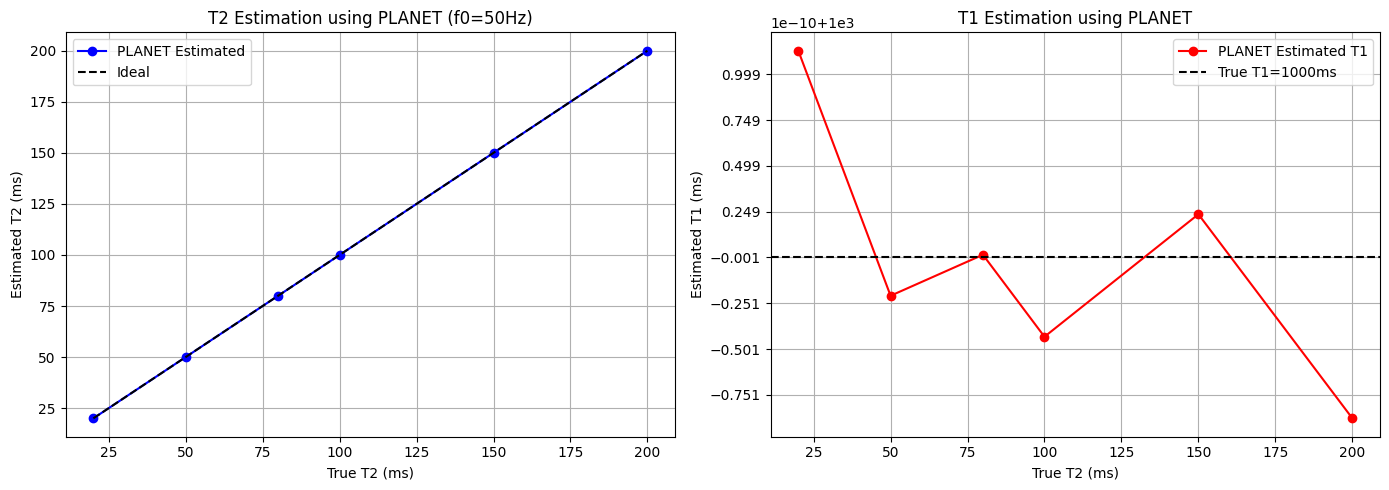

T2 Mean absolute error: 0.00 ms
T1 Mean absolute error: 0.00 ms


In [160]:
# Test T1/T2 estimation using PLANET algorithm
# PLANET requires OFF-RESONANCE signals to form ellipses in the complex plane

true_t2_values = np.array([0.02, 0.05, 0.08, 0.1, 0.15, 0.2])
T1_fixed = 1.0  # Fixed T1
TR = TRs[0]  # Use first TR for PLANET
f0 = 50  # Off-resonance frequency in Hz (REQUIRED for PLANET!)

estimated_t1_planet = []
estimated_t2_planet = []

for t2 in true_t2_values:
    # Simulate with OFF-RESONANCE (f0 != 0) - this creates the ellipse
    TE = TR / 2
    signals = ssfp(T1_fixed, t2, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    # PLANET estimation
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1_planet.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_planet.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1_planet = np.array(estimated_t1_planet)
estimated_t2_planet = np.array(estimated_t2_planet)

# Print actual values for debugging
print("Test 1: Varying T2, Fixed T1=1000ms")
print("-" * 50)
print(f"{'True T2 (ms)':<15} {'Est T2 (ms)':<15} {'Est T1 (ms)':<15}")
for i, t2 in enumerate(true_t2_values):
    print(f"{t2*1000:<15.1f} {estimated_t2_planet[i]*1000:<15.2f} {estimated_t1_planet[i]*1000:<15.2f}")
print()

# Plot T2 estimation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t2_values * 1000, estimated_t2_planet * 1000, 'bo-', label='PLANET Estimated')
axes[0].plot(true_t2_values * 1000, true_t2_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T2 (ms)')
axes[0].set_ylabel('Estimated T2 (ms)')
axes[0].set_title(f'T2 Estimation using PLANET (f0={f0}Hz)')
axes[0].legend()
axes[0].grid(True)

# Plot T1 estimation  
axes[1].plot(true_t2_values * 1000, estimated_t1_planet * 1000, 'ro-', label='PLANET Estimated T1')
axes[1].axhline(T1_fixed * 1000, color='k', linestyle='--', label=f'True T1={T1_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T2 (ms)')
axes[1].set_ylabel('Estimated T1 (ms)')
axes[1].set_title('T1 Estimation using PLANET')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_planet - true_t2_values)) * 1000:.2f} ms")
print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1_planet - T1_fixed)) * 1000:.2f} ms")

## Test T1 Estimation with PLANET (varying T1)

Test 2: Varying T1, Fixed T2=100ms
--------------------------------------------------
True T1 (ms)    Est T1 (ms)     Est T2 (ms)    
300.0           300.00          100.00         
500.0           500.00          100.00         
800.0           800.00          100.00         
1000.0          1000.00         100.00         
1500.0          1500.00         100.00         
2000.0          2000.00         100.00         



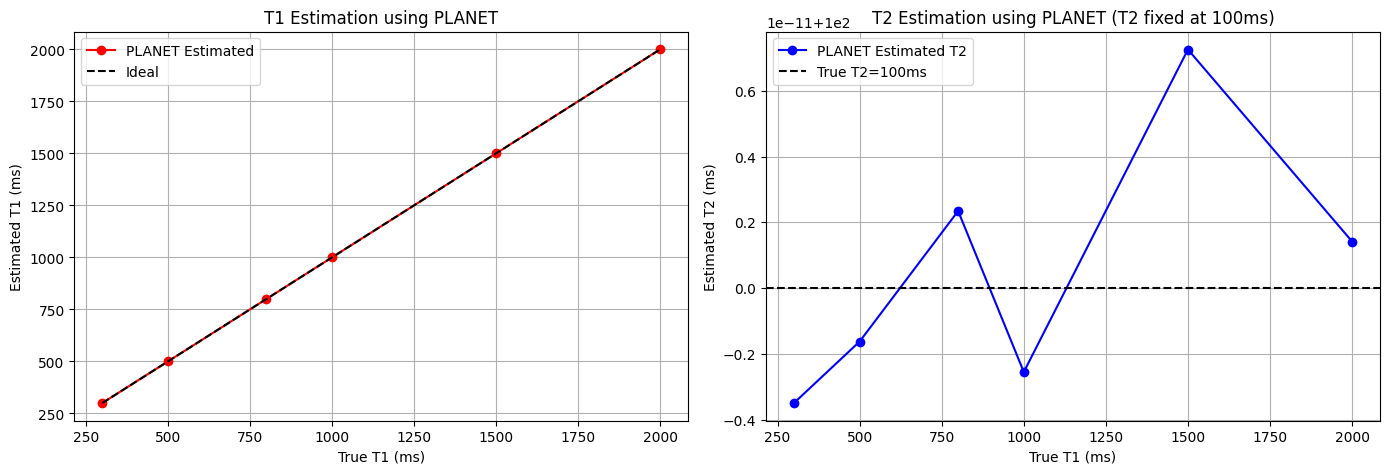

T1 Mean absolute error: 0.00 ms
T2 Mean absolute error: 0.00 ms


In [161]:
# Test PLANET T1 estimation with varying T1 values
true_t1_values = np.array([0.3, 0.5, 0.8, 1.0, 1.5, 2.0])
T2_fixed = 0.1  # Fixed T2
TR = TRs[0]
f0 = 50  # Off-resonance in Hz

estimated_t1 = []
estimated_t2_check = []

for t1 in true_t1_values:
    # Simulate with off-resonance
    TE = TR / 2
    signals = ssfp(t1, T2_fixed, TR, TE, alpha, dphi=pcs, field_map=f0)
    
    t1_est, t2_est, f0_est = estimate_t1_t2_planet(
        signals[np.newaxis, :], TR, alpha, npcs
    )
    # Extract scalar values
    estimated_t1.append(float(np.atleast_1d(t1_est)[0]))
    estimated_t2_check.append(float(np.atleast_1d(t2_est)[0]))

estimated_t1 = np.array(estimated_t1)
estimated_t2_check = np.array(estimated_t2_check)

# Print actual values for debugging
print("Test 2: Varying T1, Fixed T2=100ms")
print("-" * 50)
print(f"{'True T1 (ms)':<15} {'Est T1 (ms)':<15} {'Est T2 (ms)':<15}")
for i, t1 in enumerate(true_t1_values):
    print(f"{t1*1000:<15.1f} {estimated_t1[i]*1000:<15.2f} {estimated_t2_check[i]*1000:<15.2f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(true_t1_values * 1000, estimated_t1 * 1000, 'ro-', label='PLANET Estimated')
axes[0].plot(true_t1_values * 1000, true_t1_values * 1000, 'k--', label='Ideal')
axes[0].set_xlabel('True T1 (ms)')
axes[0].set_ylabel('Estimated T1 (ms)')
axes[0].set_title('T1 Estimation using PLANET')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(true_t1_values * 1000, estimated_t2_check * 1000, 'bo-', label='PLANET Estimated T2')
axes[1].axhline(T2_fixed * 1000, color='k', linestyle='--', label=f'True T2={T2_fixed*1000:.0f}ms')
axes[1].set_xlabel('True T1 (ms)')
axes[1].set_ylabel('Estimated T2 (ms)')
axes[1].set_title('T2 Estimation using PLANET (T2 fixed at 100ms)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"T1 Mean absolute error: {np.mean(np.abs(estimated_t1 - true_t1_values)) * 1000:.2f} ms")
print(f"T2 Mean absolute error: {np.mean(np.abs(estimated_t2_check - T2_fixed)) * 1000:.2f} ms")

## Compare Standard vs Compensated GASP

In [162]:
# Create spectral target profile (Gaussian passband)
#D = responses.gaussian(WIDTH, bw=0.2, shift=0)
D = responses.bandpass(WIDTH, bw=0.2, shift=0)

# Training tissue: Gray Matter (T2/T1 = 0.111, matching analysis notebook)
TRAIN_T1, TRAIN_T2 = 0.9, 0.1
I_train = simulate_tissue(T1=TRAIN_T1, T2=TRAIN_T2)

# Train both methods WITH L2 regularization (matching analysis notebook)
_, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)

# For compensated GASP: use KNOWN T1/T2 values (since we're simulating)
_, coeffs_comp, meta = train_compensated_gasp(
    I_train, D, TRs, alpha, npcs, method='affine',
    known_t1=TRAIN_T1, known_t2=TRAIN_T2,  # Use known values!
    useL2=True, lam=1e-2
)

# Test tissues with different T2/T1 ratios
test_tissues = {
    'Gray Matter (train)': {'T1': 0.9, 'T2': 0.1},    # T2/T1 = 0.111
    'Muscle':              {'T1': 0.9, 'T2': 0.05},   # T2/T1 = 0.055
    'White Matter':        {'T1': 0.6, 'T2': 0.08},   # T2/T1 = 0.133
    'Fat':                 {'T1': 0.25, 'T2': 0.07},  # T2/T1 = 0.28
}

results = []
for name, params in test_tissues.items():
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = run_gasp(I_test, coeffs_std, method='affine')
    # Use KNOWN T1/T2 for the test tissue
    out_comp = run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )

    # Compute RMSE relative to target profile
    rmse_std = np.sqrt(np.mean((np.abs(out_std).flatten() - D) ** 2))
    rmse_comp = np.sqrt(np.mean((np.abs(out_comp).flatten() - D) ** 2))

    results.append({
        'tissue': name,
        'T1': params['T1'],
        'T2': params['T2'],
        'T2/T1': params['T2'] / params['T1'],
        'RMSE_standard': rmse_std,
        'RMSE_compensated': rmse_comp,
        'improvement_%': (rmse_std - rmse_comp) / rmse_std * 100
    })

# Display results
print('=' * 75)
print('AMPLITUDE COMPENSATION RESULTS')
print('=' * 75)
print(f'Training tissue: T1={TRAIN_T1*1000:.0f}ms, T2={TRAIN_T2*1000:.0f}ms, T2/T1={TRAIN_T2/TRAIN_T1:.3f}')
print()
print(f"{'Tissue':<24} {'T2/T1':<8} {'Std RMSE':<12} {'Comp RMSE':<12} {'Improvement':<12}")
print('-' * 75)

for r in results:
    print(f"{r['tissue']:<24} {r['T2/T1']:<8.3f} {r['RMSE_standard']:<12.4f} {r['RMSE_compensated']:<12.4f} {r['improvement_%']:>+8.1f}%")

print('=' * 75)
print('Amplitude compensation normalizes signals across tissue types!')

AMPLITUDE COMPENSATION RESULTS
Training tissue: T1=900ms, T2=100ms, T2/T1=0.111

Tissue                   T2/T1    Std RMSE     Comp RMSE    Improvement 
---------------------------------------------------------------------------
Gray Matter (train)      0.111    0.0589       0.0590           -0.3%
Muscle                   0.056    0.1827       0.0711          +61.1%
White Matter             0.133    0.0808       0.0586          +27.6%
Fat                      0.280    0.3771       0.0694          +81.6%
Amplitude compensation normalizes signals across tissue types!


## Visualize Outputs

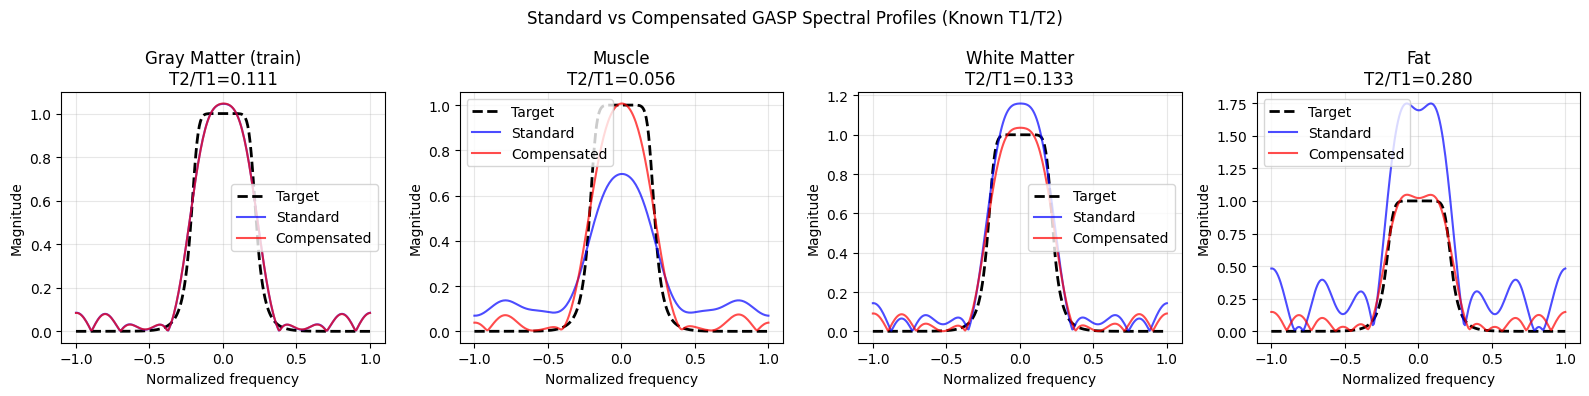

In [163]:
# Visualize spectral profiles
x = np.linspace(-1, 1, WIDTH)

fig, axes = plt.subplots(1, len(test_tissues), figsize=(16, 4))

for i, (name, params) in enumerate(test_tissues.items()):
    I_test = simulate_tissue(T1=params['T1'], T2=params['T2'])

    out_std = np.abs(run_gasp(I_test, coeffs_std, method='affine')).flatten()
    out_comp = np.abs(run_compensated_gasp(
        I_test, coeffs_comp, meta, method='affine',
        known_t1=params['T1'], known_t2=params['T2']
    )).flatten()

    axes[i].plot(x, D, 'k--', label='Target', linewidth=2)
    axes[i].plot(x, out_std, 'b-', label='Standard', alpha=0.7)
    axes[i].plot(x, out_comp, 'r-', label='Compensated', alpha=0.7)
    axes[i].set_title(f'{name}\nT2/T1={params["T2"]/params["T1"]:.3f}')
    axes[i].set_xlabel('Normalized frequency')
    axes[i].set_ylabel('Magnitude')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Standard vs Compensated GASP Spectral Profiles (Known T1/T2)')
plt.tight_layout()
plt.show()

## Training α vs Evaluation T2/T1 Heatmaps

This analysis shows how the training flip angle affects GASP performance across different tissue types (T2/T1 ratios), comparing standard GASP vs amplitude-compensated GASP.

In [164]:
# Sensitivity analysis: Training α vs Evaluation T2/T1

# Define parameter grids (higher resolution for smooth contours)
ALPHA_VALUES = np.arange(5, 95, 5)  # 5, 10, 15, ..., 90 degrees (18 values)
N_EVAL_RATIOS = 30  # Number of T2/T1 ratio values
EVAL_T2_T1_RATIOS = np.linspace(0.03, 0.35, N_EVAL_RATIOS)  # Smooth range covering tissues
T1_BASE = 1.0
TRAIN_T2_T1 = 0.1  # Fixed training tissue (Gray Matter-like)

n_alphas = len(ALPHA_VALUES)
n_eval_ratios = len(EVAL_T2_T1_RATIOS)

# MSE matrices: [alpha_idx, eval_ratio_idx]
mse_alpha_std = np.zeros((n_alphas, n_eval_ratios))
mse_alpha_comp = np.zeros((n_alphas, n_eval_ratios))

print("Computing Training α vs Evaluation T2/T1 heatmaps...")
print(f"Training tissue: T2/T1 = {TRAIN_T2_T1}")
print(f"Grid: {n_alphas} alphas x {n_eval_ratios} T2/T1 ratios = {n_alphas * n_eval_ratios} combinations")
print()

# Need to rebuild PARAMS for each alpha
def build_params_for_alpha(alpha_deg):
    """Build SSFPParams for a specific flip angle."""
    alpha_rad = np.deg2rad(alpha_deg)
    n_acq_local = npcs * len(TRs)
    alpha_list = [alpha_rad] * n_acq_local
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs:
            TR_list.append(tr)
            pc_list.append(pc)
    return SSFPParams(n_acq_local, alpha_list, TR_list, pc_list)

def simulate_tissue_alpha(T1, T2, alpha_deg):
    """Simulate tissue with specific flip angle."""
    params = build_params_for_alpha(alpha_deg)
    return simulate_ssfp_simple(
        width=WIDTH, height=HEIGHT,
        T1=T1, T2=T2,
        params=params,
        minTR=TRs[0]
    )

for i, alpha_deg in enumerate(ALPHA_VALUES):
    train_T1 = T1_BASE
    train_T2 = TRAIN_T2_T1 * T1_BASE
    alpha_rad = np.deg2rad(alpha_deg)
    
    # Simulate training data with this alpha
    I_train = simulate_tissue_alpha(T1=train_T1, T2=train_T2, alpha_deg=alpha_deg)
    
    # Train standard GASP
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    
    # Train compensated GASP
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha_rad, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2,
        useL2=True, lam=1e-2
    )
    
    # Evaluate on all test tissues
    for j, eval_ratio in enumerate(EVAL_T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        
        I_test = simulate_tissue_alpha(T1=eval_T1, T2=eval_T2, alpha_deg=alpha_deg)
        
        # Standard GASP
        out_std = run_gasp(I_test, coeffs_std, method='affine')
        mse_std = np.mean((np.abs(out_std).flatten() - D) ** 2)
        mse_alpha_std[i, j] = mse_std
        
        # Compensated GASP
        out_comp = run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )
        mse_comp = np.mean((np.abs(out_comp).flatten() - D) ** 2)
        mse_alpha_comp[i, j] = mse_comp
    
    print(f"  α={alpha_deg:2d}°: Std MSE={mse_alpha_std[i].mean():.4f}, Comp MSE={mse_alpha_comp[i].mean():.4f}")

print("\nHeatmap computation complete!")
print(f"Standard GASP - Mean MSE: {mse_alpha_std.mean():.6f}")
print(f"Compensated GASP - Mean MSE: {mse_alpha_comp.mean():.6f}")

Computing Training α vs Evaluation T2/T1 heatmaps...
Training tissue: T2/T1 = 0.1
Grid: 18 alphas x 30 T2/T1 ratios = 540 combinations

  α= 5°: Std MSE=0.0166, Comp MSE=0.0175
  α=10°: Std MSE=0.0067, Comp MSE=0.0060
  α=15°: Std MSE=0.0107, Comp MSE=0.0068
  α=20°: Std MSE=0.0177, Comp MSE=0.0079
  α=25°: Std MSE=0.0236, Comp MSE=0.0067
  α=30°: Std MSE=0.0319, Comp MSE=0.0060
  α=35°: Std MSE=0.0430, Comp MSE=0.0061
  α=40°: Std MSE=0.0549, Comp MSE=0.0059
  α=45°: Std MSE=0.0682, Comp MSE=0.0059
  α=50°: Std MSE=0.0825, Comp MSE=0.0059
  α=55°: Std MSE=0.0966, Comp MSE=0.0058
  α=60°: Std MSE=0.1099, Comp MSE=0.0055
  α=65°: Std MSE=0.1221, Comp MSE=0.0052
  α=70°: Std MSE=0.1330, Comp MSE=0.0048
  α=75°: Std MSE=0.1430, Comp MSE=0.0045
  α=80°: Std MSE=0.1527, Comp MSE=0.0044
  α=85°: Std MSE=0.1622, Comp MSE=0.0045
  α=90°: Std MSE=0.1716, Comp MSE=0.0047

Heatmap computation complete!
Standard GASP - Mean MSE: 0.080385
Compensated GASP - Mean MSE: 0.006329


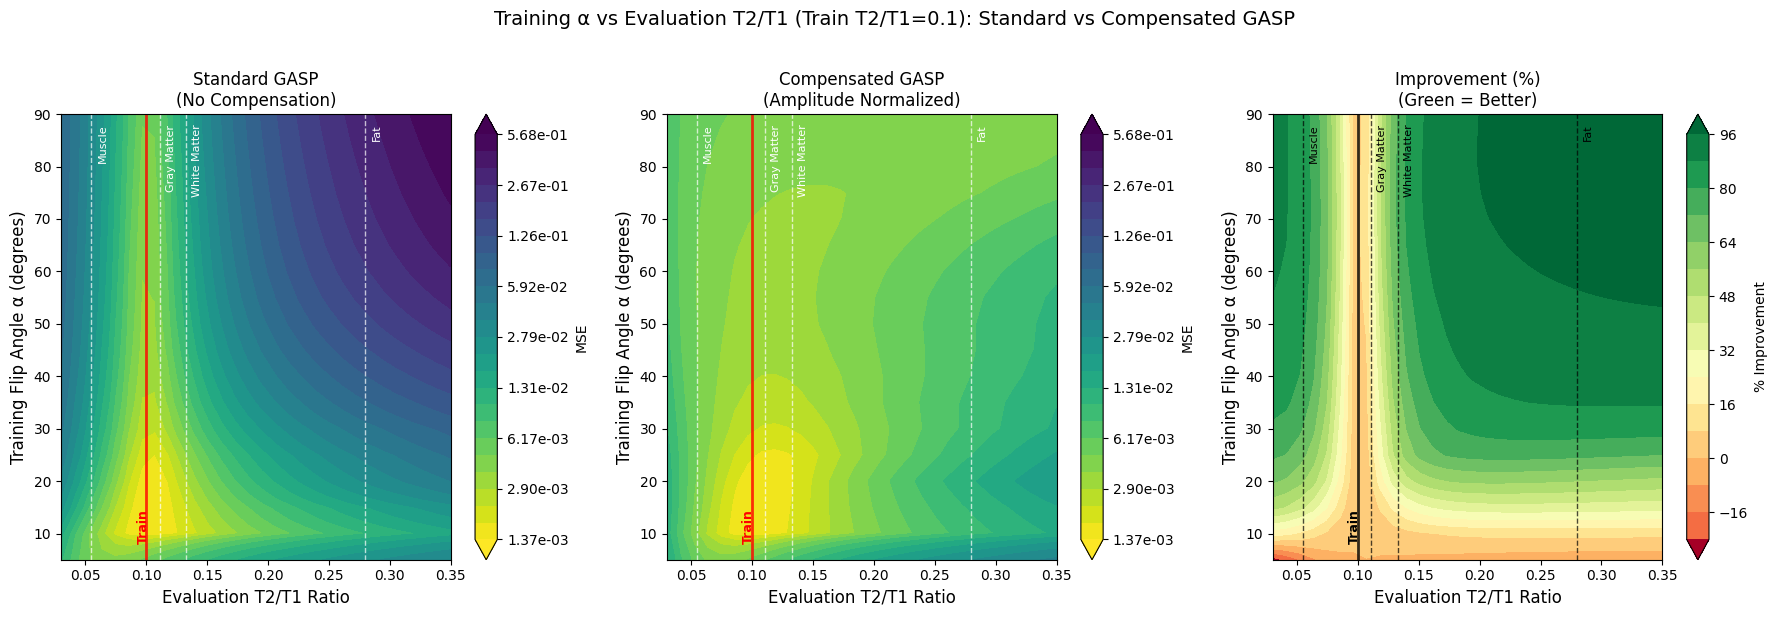


Optimal Flip Angle Analysis:
------------------------------------------------------------
Standard GASP - Best α: 10° (Mean MSE: 0.006670)
Compensated GASP - Best α: 80° (Mean MSE: 0.004404)


In [165]:
# Plot heatmaps: Training α vs Evaluation T2/T1 (contourf style matching conditional_gasp_sensitivity_analysis)
from matplotlib import ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create meshgrid for contourf
X, Y = np.meshgrid(EVAL_T2_T1_RATIOS, ALPHA_VALUES)

# Reference tissue types with their T2/T1 ratios (for vertical lines)
TISSUE_REFS = {
    'Muscle': 0.055,
    'Gray Matter': 0.111,
    'White Matter': 0.133,
    'Fat': 0.28,
}

# Unified color scale (using vmin/vmax for both standard and compensated)
vmin_alpha = min(mse_alpha_std.min(), mse_alpha_comp.min())
vmax_alpha = max(mse_alpha_std.max(), mse_alpha_comp.max())

# Standard GASP heatmap (log scale)
levels = np.logspace(np.log10(vmin_alpha + 1e-12), np.log10(vmax_alpha), 25)
cs0 = axes[0].contourf(X, Y, mse_alpha_std, levels=levels, locator=ticker.LogLocator(), 
                        cmap='viridis_r', extend='both')
cbar0 = plt.colorbar(cs0, ax=axes[0], label='MSE', format='%.2e')

# Add tissue reference lines
for name, ratio in TISSUE_REFS.items():
    if ratio >= EVAL_T2_T1_RATIOS.min() and ratio <= EVAL_T2_T1_RATIOS.max():
        axes[0].axvline(ratio, color='white', linestyle='--', alpha=0.7, linewidth=1)
        axes[0].text(ratio + 0.005, ALPHA_VALUES.max() - 2, name,
                    color='white', fontsize=8, rotation=90, va='top')

# Mark training tissue ratio
axes[0].axvline(TRAIN_T2_T1, color='red', linestyle='-', linewidth=2, alpha=0.8)
axes[0].text(TRAIN_T2_T1 - 0.008, ALPHA_VALUES.min() + 3, 'Train', 
             color='red', fontsize=9, rotation=90, va='bottom', fontweight='bold')

axes[0].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[0].set_ylabel('Training Flip Angle α (degrees)', fontsize=12)
axes[0].set_title('Standard GASP\n(No Compensation)')

# Compensated GASP heatmap (log scale)
cs1 = axes[1].contourf(X, Y, mse_alpha_comp, levels=levels, locator=ticker.LogLocator(), 
                        cmap='viridis_r', extend='both')
cbar1 = plt.colorbar(cs1, ax=axes[1], label='MSE', format='%.2e')

# Add tissue reference lines
for name, ratio in TISSUE_REFS.items():
    if ratio >= EVAL_T2_T1_RATIOS.min() and ratio <= EVAL_T2_T1_RATIOS.max():
        axes[1].axvline(ratio, color='white', linestyle='--', alpha=0.7, linewidth=1)
        axes[1].text(ratio + 0.005, ALPHA_VALUES.max() - 2, name,
                    color='white', fontsize=8, rotation=90, va='top')

axes[1].axvline(TRAIN_T2_T1, color='red', linestyle='-', linewidth=2, alpha=0.8)
axes[1].text(TRAIN_T2_T1 - 0.008, ALPHA_VALUES.min() + 3, 'Train', 
             color='red', fontsize=9, rotation=90, va='bottom', fontweight='bold')

axes[1].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[1].set_ylabel('Training Flip Angle α (degrees)', fontsize=12)
axes[1].set_title('Compensated GASP\n(Amplitude Normalized)')

# Improvement heatmap (linear scale, RdYlGn colormap)
improvement_alpha = (mse_alpha_std - mse_alpha_comp) / mse_alpha_std * 100
cs2 = axes[2].contourf(X, Y, improvement_alpha, levels=20, cmap='RdYlGn', 
                        vmin=-50, vmax=100, extend='both')
cbar2 = plt.colorbar(cs2, ax=axes[2], label='% Improvement')

# Add tissue reference lines (black for contrast on RdYlGn)
for name, ratio in TISSUE_REFS.items():
    if ratio >= EVAL_T2_T1_RATIOS.min() and ratio <= EVAL_T2_T1_RATIOS.max():
        axes[2].axvline(ratio, color='black', linestyle='--', alpha=0.7, linewidth=1)
        axes[2].text(ratio + 0.005, ALPHA_VALUES.max() - 2, name,
                    color='black', fontsize=8, rotation=90, va='top')

axes[2].axvline(TRAIN_T2_T1, color='black', linestyle='-', linewidth=2, alpha=0.8)
axes[2].text(TRAIN_T2_T1 - 0.008, ALPHA_VALUES.min() + 3, 'Train', 
             color='black', fontsize=9, rotation=90, va='bottom', fontweight='bold')

axes[2].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[2].set_ylabel('Training Flip Angle α (degrees)', fontsize=12)
axes[2].set_title('Improvement (%)\n(Green = Better)')

plt.suptitle(f'Training α vs Evaluation T2/T1 (Train T2/T1={TRAIN_T2_T1}): Standard vs Compensated GASP', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print best alpha for each method
print("\nOptimal Flip Angle Analysis:")
print("-" * 60)
mean_mse_per_alpha_std = mse_alpha_std.mean(axis=1)
mean_mse_per_alpha_comp = mse_alpha_comp.mean(axis=1)
best_alpha_std = ALPHA_VALUES[np.argmin(mean_mse_per_alpha_std)]
best_alpha_comp = ALPHA_VALUES[np.argmin(mean_mse_per_alpha_comp)]
print(f"Standard GASP - Best α: {best_alpha_std}° (Mean MSE: {mean_mse_per_alpha_std.min():.6f})")
print(f"Compensated GASP - Best α: {best_alpha_comp}° (Mean MSE: {mean_mse_per_alpha_comp.min():.6f})")

## Training T2/T1 vs Evaluation T2/T1 Heatmaps

This analysis shows how GASP coefficients trained on one tissue type generalize to other tissues, comparing standard GASP (no compensation) vs amplitude-compensated GASP.

In [166]:
# Sensitivity analysis: Training T2/T1 vs Evaluation T2/T1

# Define tissue grid for analysis (higher resolution for smooth contours)
N_RATIOS = 30  # Number of T2/T1 ratio values
T2_T1_RATIOS = np.linspace(0.03, 0.35, N_RATIOS)  # Smooth range covering tissues
T1_BASE = 1.0  # Fixed T1 for all tissues

# Reference tissues for annotation
TISSUE_REFS = {
    'Muscle': 0.055,
    'Gray Matter': 0.111,
    'White Matter': 0.133,
    'Fat': 0.28,
}

n_ratios = len(T2_T1_RATIOS)

# MSE matrices: [train_idx, eval_idx]
mse_standard = np.zeros((n_ratios, n_ratios))
mse_compensated = np.zeros((n_ratios, n_ratios))

print("Computing Training T2/T1 vs Evaluation T2/T1 heatmaps...")
print(f"Grid: {n_ratios} x {n_ratios} = {n_ratios**2} combinations")
print()

for i, train_ratio in enumerate(T2_T1_RATIOS):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    
    # Simulate training data
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    
    # Train standard GASP
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    
    # Train compensated GASP
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2,
        useL2=True, lam=1e-2
    )
    
    # Evaluate on all test tissues
    for j, eval_ratio in enumerate(T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        
        I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
        
        # Standard GASP
        out_std = run_gasp(I_test, coeffs_std, method='affine')
        mse_std = np.mean((np.abs(out_std).flatten() - D) ** 2)
        mse_standard[i, j] = mse_std
        
        # Compensated GASP
        out_comp = run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )
        mse_comp = np.mean((np.abs(out_comp).flatten() - D) ** 2)
        mse_compensated[i, j] = mse_comp
    
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Train T2/T1={train_ratio:.3f}: Std MSE={mse_standard[i].mean():.4f}, Comp MSE={mse_compensated[i].mean():.4f}")

print("\nHeatmap computation complete!")
print(f"Standard GASP - Mean MSE: {mse_standard.mean():.6f}")
print(f"Compensated GASP - Mean MSE: {mse_compensated.mean():.6f}")
print(f"Overall improvement: {(1 - mse_compensated.mean()/mse_standard.mean())*100:.1f}%")

Computing Training T2/T1 vs Evaluation T2/T1 heatmaps...
Grid: 30 x 30 = 900 combinations

  Train T2/T1=0.030: Std MSE=2.3565, Comp MSE=0.0145
  Train T2/T1=0.074: Std MSE=0.2528, Comp MSE=0.0070
  Train T2/T1=0.129: Std MSE=0.0525, Comp MSE=0.0047
  Train T2/T1=0.184: Std MSE=0.0252, Comp MSE=0.0043
  Train T2/T1=0.240: Std MSE=0.0237, Comp MSE=0.0044
  Train T2/T1=0.295: Std MSE=0.0275, Comp MSE=0.0048
  Train T2/T1=0.350: Std MSE=0.0322, Comp MSE=0.0052

Heatmap computation complete!
Standard GASP - Mean MSE: 0.193044
Compensated GASP - Mean MSE: 0.005609
Overall improvement: 97.1%


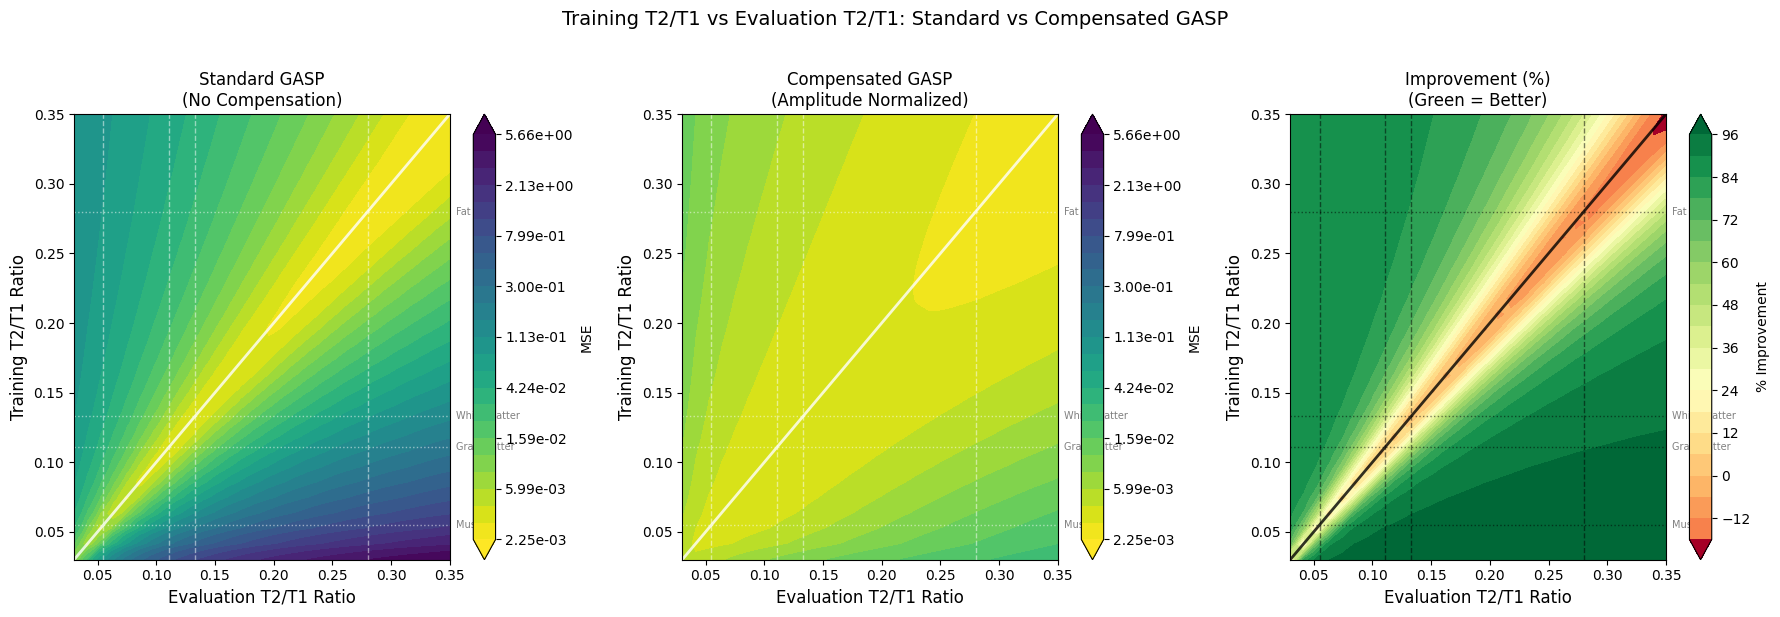


Key Observations:
- Standard GASP: Best performance along diagonal (train=eval tissue)
- Compensated GASP: Uniform performance across all combinations
- White solid line shows train=eval diagonal
- Dashed lines: tissue reference (vertical=eval, horizontal=train)


In [167]:
# Plot heatmaps: Training T2/T1 vs Evaluation T2/T1 (contourf style)
from matplotlib import ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create meshgrid for contourf
X, Y = np.meshgrid(T2_T1_RATIOS, T2_T1_RATIOS)

# Unified color scale
vmin = min(mse_standard.min(), mse_compensated.min())
vmax = max(mse_standard.max(), mse_compensated.max())

# Standard GASP heatmap (log scale)
levels = np.logspace(np.log10(vmin + 1e-12), np.log10(vmax), 25)
cs0 = axes[0].contourf(X, Y, mse_standard, levels=levels, locator=ticker.LogLocator(), 
                        cmap='viridis_r', extend='both')
cbar0 = plt.colorbar(cs0, ax=axes[0], label='MSE', format='%.2e')

# Add tissue reference lines (vertical for eval, horizontal for train)
for name, ratio in TISSUE_REFS.items():
    if ratio >= T2_T1_RATIOS.min() and ratio <= T2_T1_RATIOS.max():
        # Vertical line (eval tissue)
        axes[0].axvline(ratio, color='white', linestyle='--', alpha=0.5, linewidth=1)
        # Horizontal line (train tissue)
        axes[0].axhline(ratio, color='white', linestyle=':', alpha=0.5, linewidth=1)
        # Label on right edge
        axes[0].text(T2_T1_RATIOS.max() + 0.005, ratio, name,
                    color='gray', fontsize=7, va='center', ha='left')

# Add diagonal line (train = eval)
axes[0].plot([T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             [T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             'w-', linewidth=2, alpha=0.8, label='Train=Eval')

axes[0].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[0].set_ylabel('Training T2/T1 Ratio', fontsize=12)
axes[0].set_title('Standard GASP\n(No Compensation)')

# Compensated GASP heatmap (log scale)
cs1 = axes[1].contourf(X, Y, mse_compensated, levels=levels, locator=ticker.LogLocator(), 
                        cmap='viridis_r', extend='both')
cbar1 = plt.colorbar(cs1, ax=axes[1], label='MSE', format='%.2e')

# Add tissue reference lines
for name, ratio in TISSUE_REFS.items():
    if ratio >= T2_T1_RATIOS.min() and ratio <= T2_T1_RATIOS.max():
        axes[1].axvline(ratio, color='white', linestyle='--', alpha=0.5, linewidth=1)
        axes[1].axhline(ratio, color='white', linestyle=':', alpha=0.5, linewidth=1)
        axes[1].text(T2_T1_RATIOS.max() + 0.005, ratio, name,
                    color='gray', fontsize=7, va='center', ha='left')

axes[1].plot([T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             [T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             'w-', linewidth=2, alpha=0.8)

axes[1].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[1].set_ylabel('Training T2/T1 Ratio', fontsize=12)
axes[1].set_title('Compensated GASP\n(Amplitude Normalized)')

# Improvement heatmap (linear scale, RdYlGn colormap)
improvement = (mse_standard - mse_compensated) / mse_standard * 100
cs2 = axes[2].contourf(X, Y, improvement, levels=20, cmap='RdYlGn', 
                        vmin=-50, vmax=100, extend='both')
cbar2 = plt.colorbar(cs2, ax=axes[2], label='% Improvement')

# Add tissue reference lines (black for contrast)
for name, ratio in TISSUE_REFS.items():
    if ratio >= T2_T1_RATIOS.min() and ratio <= T2_T1_RATIOS.max():
        axes[2].axvline(ratio, color='black', linestyle='--', alpha=0.5, linewidth=1)
        axes[2].axhline(ratio, color='black', linestyle=':', alpha=0.5, linewidth=1)
        axes[2].text(T2_T1_RATIOS.max() + 0.005, ratio, name,
                    color='gray', fontsize=7, va='center', ha='left')

axes[2].plot([T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             [T2_T1_RATIOS.min(), T2_T1_RATIOS.max()], 
             'k-', linewidth=2, alpha=0.8)

axes[2].set_xlabel('Evaluation T2/T1 Ratio', fontsize=12)
axes[2].set_ylabel('Training T2/T1 Ratio', fontsize=12)
axes[2].set_title('Improvement (%)\n(Green = Better)')

plt.suptitle('Training T2/T1 vs Evaluation T2/T1: Standard vs Compensated GASP', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print observations
print("\nKey Observations:")
print("- Standard GASP: Best performance along diagonal (train=eval tissue)")
print("- Compensated GASP: Uniform performance across all combinations")
print("- White solid line shows train=eval diagonal")
print("- Dashed lines: tissue reference (vertical=eval, horizontal=train)")

## Best/Worst Examples & Residual Distribution

Computing residuals across all parameter combinations...
Collected 900 residual profiles


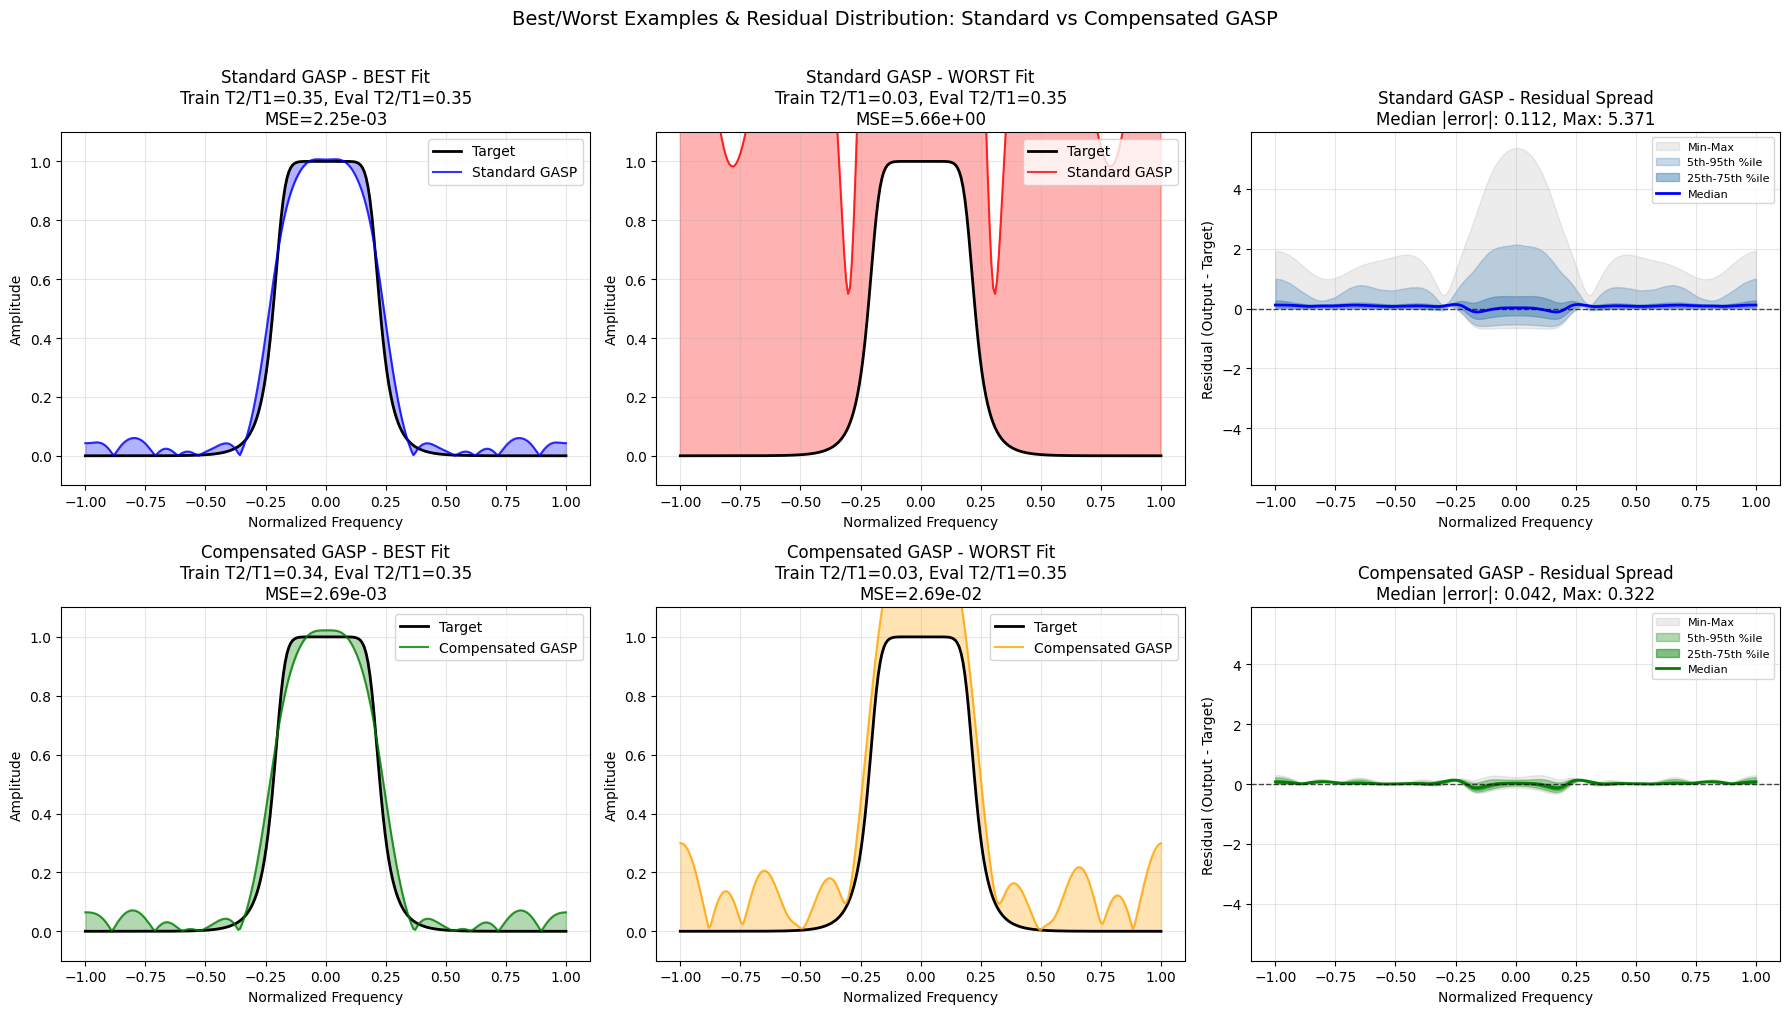

In [168]:
# Best/Worst Examples & Residual Distribution

# Find best and worst cases for standard GASP
best_std_idx = np.unravel_index(np.argmin(mse_standard), mse_standard.shape)
worst_std_idx = np.unravel_index(np.argmax(mse_standard), mse_standard.shape)

# For compensated GASP (should be uniformly good)
best_comp_idx = np.unravel_index(np.argmin(mse_compensated), mse_compensated.shape)
worst_comp_idx = np.unravel_index(np.argmax(mse_compensated), mse_compensated.shape)

# Collect all residuals for both methods
print("Computing residuals across all parameter combinations...")
all_residuals_std = []
all_residuals_comp = []

for i, train_ratio in enumerate(T2_T1_RATIOS):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    
    _, coeffs_std = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
    _, coeffs_comp, meta = train_compensated_gasp(
        I_train, D, TRs, alpha, npcs, method='affine',
        known_t1=train_T1, known_t2=train_T2, useL2=True, lam=1e-2
    )
    
    for j, eval_ratio in enumerate(T2_T1_RATIOS):
        eval_T1 = T1_BASE
        eval_T2 = eval_ratio * T1_BASE
        I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
        
        out_std = np.abs(run_gasp(I_test, coeffs_std, method='affine')).flatten()
        out_comp = np.abs(run_compensated_gasp(
            I_test, coeffs_comp, meta, method='affine',
            known_t1=eval_T1, known_t2=eval_T2
        )).flatten()
        
        all_residuals_std.append(out_std - D)
        all_residuals_comp.append(out_comp - D)

all_residuals_std = np.array(all_residuals_std)
all_residuals_comp = np.array(all_residuals_comp)
print(f"Collected {len(all_residuals_std)} residual profiles")

# Get specific examples for plotting
def get_output(train_ratio, eval_ratio, compensated=False):
    train_T1 = T1_BASE
    train_T2 = train_ratio * T1_BASE
    eval_T1 = T1_BASE
    eval_T2 = eval_ratio * T1_BASE
    
    I_train = simulate_tissue(T1=train_T1, T2=train_T2)
    I_test = simulate_tissue(T1=eval_T1, T2=eval_T2)
    
    if compensated:
        _, coeffs, meta = train_compensated_gasp(
            I_train, D, TRs, alpha, npcs, method='affine',
            known_t1=train_T1, known_t2=train_T2, useL2=True, lam=1e-2
        )
        out = run_compensated_gasp(I_test, coeffs, meta, method='affine',
                                    known_t1=eval_T1, known_t2=eval_T2)
    else:
        _, coeffs = train_gasp(I_train, D, method='affine', useL2=True, lam=1e-2)
        out = run_gasp(I_test, coeffs, method='affine')
    
    return np.abs(out).flatten()

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freq_axis = np.linspace(-1, 1, WIDTH)

# Row 1: Standard GASP
# Best case
best_train_r = T2_T1_RATIOS[best_std_idx[0]]
best_eval_r = T2_T1_RATIOS[best_std_idx[1]]
best_out_std = get_output(best_train_r, best_eval_r, compensated=False)
best_mse_std = mse_standard[best_std_idx]

axes[0, 0].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[0, 0].plot(freq_axis, best_out_std, 'b-', linewidth=1.5, label='Standard GASP', alpha=0.8)
axes[0, 0].fill_between(freq_axis, D, best_out_std, alpha=0.3, color='blue')
axes[0, 0].set_title(f'Standard GASP - BEST Fit\nTrain T2/T1={best_train_r:.2f}, Eval T2/T1={best_eval_r:.2f}\nMSE={best_mse_std:.2e}')
axes[0, 0].set_xlabel('Normalized Frequency')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([-0.1, 1.1])

# Worst case
worst_train_r = T2_T1_RATIOS[worst_std_idx[0]]
worst_eval_r = T2_T1_RATIOS[worst_std_idx[1]]
worst_out_std = get_output(worst_train_r, worst_eval_r, compensated=False)
worst_mse_std = mse_standard[worst_std_idx]

axes[0, 1].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[0, 1].plot(freq_axis, worst_out_std, 'r-', linewidth=1.5, label='Standard GASP', alpha=0.8)
axes[0, 1].fill_between(freq_axis, D, worst_out_std, alpha=0.3, color='red')
axes[0, 1].set_title(f'Standard GASP - WORST Fit\nTrain T2/T1={worst_train_r:.2f}, Eval T2/T1={worst_eval_r:.2f}\nMSE={worst_mse_std:.2e}')
axes[0, 1].set_xlabel('Normalized Frequency')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([-0.1, 1.1])

# Residual distribution - Standard GASP
res_median = np.median(all_residuals_std, axis=0)
res_p5 = np.percentile(all_residuals_std, 5, axis=0)
res_p25 = np.percentile(all_residuals_std, 25, axis=0)
res_p75 = np.percentile(all_residuals_std, 75, axis=0)
res_p95 = np.percentile(all_residuals_std, 95, axis=0)
res_min = np.min(all_residuals_std, axis=0)
res_max = np.max(all_residuals_std, axis=0)

axes[0, 2].fill_between(freq_axis, res_min, res_max, alpha=0.15, color='gray', label='Min-Max')
axes[0, 2].fill_between(freq_axis, res_p5, res_p95, alpha=0.3, color='steelblue', label='5th-95th %ile')
axes[0, 2].fill_between(freq_axis, res_p25, res_p75, alpha=0.5, color='steelblue', label='25th-75th %ile')
axes[0, 2].plot(freq_axis, res_median, 'b-', linewidth=2, label='Median')
axes[0, 2].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
max_res = max(abs(res_min).max(), abs(res_max).max())
axes[0, 2].set_ylim([-max_res*1.1, max_res*1.1])
axes[0, 2].set_title(f'Standard GASP - Residual Spread\nMedian |error|: {np.median(np.abs(all_residuals_std)):.3f}, Max: {np.abs(all_residuals_std).max():.3f}')
axes[0, 2].set_xlabel('Normalized Frequency')
axes[0, 2].set_ylabel('Residual (Output - Target)')
axes[0, 2].legend(loc='upper right', fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Compensated GASP
# Best case
best_train_r = T2_T1_RATIOS[best_comp_idx[0]]
best_eval_r = T2_T1_RATIOS[best_comp_idx[1]]
best_out_comp = get_output(best_train_r, best_eval_r, compensated=True)
best_mse_comp = mse_compensated[best_comp_idx]

axes[1, 0].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[1, 0].plot(freq_axis, best_out_comp, 'g-', linewidth=1.5, label='Compensated GASP', alpha=0.8)
axes[1, 0].fill_between(freq_axis, D, best_out_comp, alpha=0.3, color='green')
axes[1, 0].set_title(f'Compensated GASP - BEST Fit\nTrain T2/T1={best_train_r:.2f}, Eval T2/T1={best_eval_r:.2f}\nMSE={best_mse_comp:.2e}')
axes[1, 0].set_xlabel('Normalized Frequency')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([-0.1, 1.1])

# Worst case
worst_train_r = T2_T1_RATIOS[worst_comp_idx[0]]
worst_eval_r = T2_T1_RATIOS[worst_comp_idx[1]]
worst_out_comp = get_output(worst_train_r, worst_eval_r, compensated=True)
worst_mse_comp = mse_compensated[worst_comp_idx]

axes[1, 1].plot(freq_axis, D, 'k-', linewidth=2, label='Target')
axes[1, 1].plot(freq_axis, worst_out_comp, 'orange', linewidth=1.5, label='Compensated GASP', alpha=0.8)
axes[1, 1].fill_between(freq_axis, D, worst_out_comp, alpha=0.3, color='orange')
axes[1, 1].set_title(f'Compensated GASP - WORST Fit\nTrain T2/T1={worst_train_r:.2f}, Eval T2/T1={worst_eval_r:.2f}\nMSE={worst_mse_comp:.2e}')
axes[1, 1].set_xlabel('Normalized Frequency')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([-0.1, 1.1])

# Residual distribution - Compensated GASP
res_median = np.median(all_residuals_comp, axis=0)
res_p5 = np.percentile(all_residuals_comp, 5, axis=0)
res_p25 = np.percentile(all_residuals_comp, 25, axis=0)
res_p75 = np.percentile(all_residuals_comp, 75, axis=0)
res_p95 = np.percentile(all_residuals_comp, 95, axis=0)
res_min = np.min(all_residuals_comp, axis=0)
res_max = np.max(all_residuals_comp, axis=0)

axes[1, 2].fill_between(freq_axis, res_min, res_max, alpha=0.15, color='gray', label='Min-Max')
axes[1, 2].fill_between(freq_axis, res_p5, res_p95, alpha=0.3, color='green', label='5th-95th %ile')
axes[1, 2].fill_between(freq_axis, res_p25, res_p75, alpha=0.5, color='green', label='25th-75th %ile')
axes[1, 2].plot(freq_axis, res_median, 'g-', linewidth=2, label='Median')
axes[1, 2].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7)
# Use same y-axis scale as standard for fair comparison
axes[1, 2].set_ylim([-max_res*1.1, max_res*1.1])
axes[1, 2].set_title(f'Compensated GASP - Residual Spread\nMedian |error|: {np.median(np.abs(all_residuals_comp)):.3f}, Max: {np.abs(all_residuals_comp).max():.3f}')
axes[1, 2].set_xlabel('Normalized Frequency')
axes[1, 2].set_ylabel('Residual (Output - Target)')
axes[1, 2].legend(loc='upper right', fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Best/Worst Examples & Residual Distribution: Standard vs Compensated GASP', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Residual Statistics Table

In [169]:
# Residual Statistics Table

# Compute statistics for both methods
abs_residuals_std = np.abs(all_residuals_std)
abs_residuals_comp = np.abs(all_residuals_comp)

stats = {
    'Standard GASP': {
        'min': abs_residuals_std.min(),
        'max': abs_residuals_std.max(),
        'mean': abs_residuals_std.mean(),
        'median': np.median(abs_residuals_std),
        'p5': np.percentile(abs_residuals_std, 5),
        'p25': np.percentile(abs_residuals_std, 25),
        'p75': np.percentile(abs_residuals_std, 75),
        'p95': np.percentile(abs_residuals_std, 95),
    },
    'Compensated GASP': {
        'min': abs_residuals_comp.min(),
        'max': abs_residuals_comp.max(),
        'mean': abs_residuals_comp.mean(),
        'median': np.median(abs_residuals_comp),
        'p5': np.percentile(abs_residuals_comp, 5),
        'p25': np.percentile(abs_residuals_comp, 25),
        'p75': np.percentile(abs_residuals_comp, 75),
        'p95': np.percentile(abs_residuals_comp, 95),
    }
}

# Print formatted table
print("=" * 100)
print("RESIDUAL STATISTICS (Absolute Values Across All Train/Eval T2/T1 Combinations)")
print("=" * 100)
print(f"{'Method':<20} {'Min':<10} {'Max':<10} {'Mean':<10} {'Median':<10} {'5th %':<10} {'25th %':<10} {'75th %':<10} {'95th %':<10}")
print("-" * 100)

for method, s in stats.items():
    print(f"{method:<20} {s['min']:<10.4f} {s['max']:<10.4f} {s['mean']:<10.4f} {s['median']:<10.4f} "
          f"{s['p5']:<10.4f} {s['p25']:<10.4f} {s['p75']:<10.4f} {s['p95']:<10.4f}")

print("=" * 100)
print(f"\nNote: Statistics computed from {n_ratios**2} combinations ({n_ratios} train × {n_ratios} eval T2/T1 ratios)")
print(f"      Each combination evaluated across {WIDTH} frequency points")

# Improvement summary
print("\n" + "=" * 100)
print("IMPROVEMENT SUMMARY")
print("=" * 100)
print(f"{'Metric':<25} {'Standard':<15} {'Compensated':<15} {'Improvement':<15}")
print("-" * 100)

for metric in ['mean', 'median', 'max', 'p95']:
    std_val = stats['Standard GASP'][metric]
    comp_val = stats['Compensated GASP'][metric]
    improvement = (1 - comp_val / std_val) * 100
    print(f"{metric.capitalize() + ' |error|':<25} {std_val:<15.4f} {comp_val:<15.4f} {improvement:>+10.1f}%")

print("=" * 100)

# MSE summary
print("\n" + "=" * 100)
print("MSE SUMMARY")  
print("=" * 100)
print(f"{'Metric':<25} {'Standard':<15} {'Compensated':<15} {'Improvement':<15}")
print("-" * 100)
print(f"{'Mean MSE':<25} {mse_standard.mean():<15.6f} {mse_compensated.mean():<15.6f} {(1 - mse_compensated.mean()/mse_standard.mean())*100:>+10.1f}%")
print(f"{'Min MSE':<25} {mse_standard.min():<15.6f} {mse_compensated.min():<15.6f} {(1 - mse_compensated.min()/mse_standard.min())*100:>+10.1f}%")
print(f"{'Max MSE':<25} {mse_standard.max():<15.6f} {mse_compensated.max():<15.6f} {(1 - mse_compensated.max()/mse_standard.max())*100:>+10.1f}%")
print(f"{'Std MSE':<25} {mse_standard.std():<15.6f} {mse_compensated.std():<15.6f} {(1 - mse_compensated.std()/mse_standard.std())*100:>+10.1f}%")
print("=" * 100)
print("\nAmplitude compensation significantly reduces MSE variance across tissue types!")

RESIDUAL STATISTICS (Absolute Values Across All Train/Eval T2/T1 Combinations)
Method               Min        Max        Mean       Median     5th %      25th %     75th %     95th %    
----------------------------------------------------------------------------------------------------
Standard GASP        0.0000     5.3706     0.2257     0.1125     0.0086     0.0495     0.2266     0.8282    
Compensated GASP     0.0000     0.3216     0.0555     0.0422     0.0023     0.0154     0.0797     0.1499    

Note: Statistics computed from 900 combinations (30 train × 30 eval T2/T1 ratios)
      Each combination evaluated across 256 frequency points

IMPROVEMENT SUMMARY
Metric                    Standard        Compensated     Improvement    
----------------------------------------------------------------------------------------------------
Mean |error|              0.2257          0.0555               +75.4%
Median |error|            0.1125          0.0422               +62.4%
Max |error|  

## Tissue Contrast Analysis: Standard vs Compensated GASP

This analysis creates a multi-tissue phantom to visualize how amplitude compensation affects tissue contrast. We compare:
- **Raw bSSFP signal** (for reference)
- **Standard GASP** (trained on Gray Matter)
- **Compensated GASP** (amplitude normalized)

And calculate **Contrast-to-Noise Ratio (CNR)** between tissue pairs.

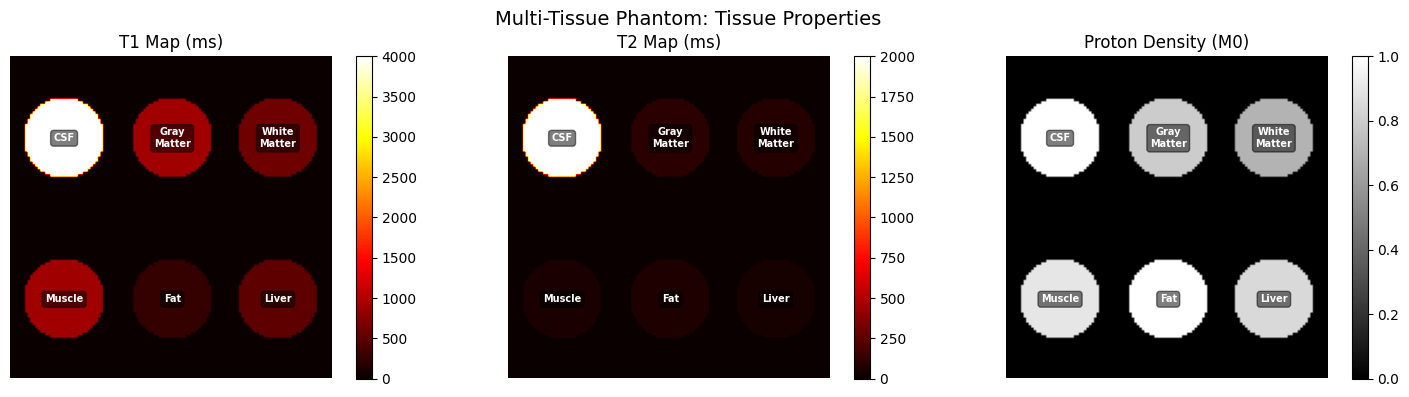

Phantom tissues:
----------------------------------------------------------------------
Tissue          T1 (ms)      T2 (ms)      T2/T1      M0      
----------------------------------------------------------------------
CSF             4000         2000         0.500      1.00    
Gray Matter     900          100          0.111      0.80    
White Matter    600          80           0.133      0.70    
Muscle          900          50           0.056      0.90    
Fat             250          70           0.280      1.00    
Liver           500          40           0.080      0.85    


In [170]:
# Create multi-tissue phantom for contrast analysis
from gasp.ssfp import add_noise

# Phantom parameters
PHANTOM_SIZE = 128
NOISE_SIGMA = 0.02  # Noise level

# Define tissues with T1, T2, and relative proton density (M0)
PHANTOM_TISSUES = {
    'CSF':          {'T1': 4.0,  'T2': 2.0,   'M0': 1.0,  'color': 'cyan'},
    'Gray Matter':  {'T1': 0.9,  'T2': 0.1,   'M0': 0.8,  'color': 'gray'},
    'White Matter': {'T1': 0.6,  'T2': 0.08,  'M0': 0.7,  'color': 'white'},
    'Muscle':       {'T1': 0.9,  'T2': 0.05,  'M0': 0.9,  'color': 'brown'},
    'Fat':          {'T1': 0.25, 'T2': 0.07,  'M0': 1.0,  'color': 'yellow'},
    'Liver':        {'T1': 0.5,  'T2': 0.04,  'M0': 0.85, 'color': 'darkred'},
}

def create_circular_phantom(size, tissues):
    """Create a phantom with circular tissue regions arranged in a centered grid."""
    phantom_t1 = np.zeros((size, size))
    phantom_t2 = np.zeros((size, size))
    phantom_m0 = np.zeros((size, size))
    tissue_mask = np.zeros((size, size), dtype=int)
    
    n_tissues = len(tissues)
    cols = 3
    rows = 2
    
    radius = size // 8
    
    tissue_names = list(tissues.keys())
    tissue_centers = {}
    
    for idx, name in enumerate(tissue_names):
        row = idx // cols
        col = idx % cols
        
        # Center the grid: for n items, positions are at (2*i + 1) / (2*n) of the size
        # For 3 columns: 1/6, 3/6, 5/6 of width
        # For 2 rows: 1/4, 3/4 of height
        cx = int((2 * col + 1) * size / (2 * cols))
        cy = int((2 * row + 1) * size / (2 * rows))
        
        tissue_centers[name] = (cx, cy)
        
        # Create circular region
        y, x = np.ogrid[:size, :size]
        mask = (x - cx)**2 + (y - cy)**2 < radius**2
        
        phantom_t1[mask] = tissues[name]['T1']
        phantom_t2[mask] = tissues[name]['T2']
        phantom_m0[mask] = tissues[name]['M0']
        tissue_mask[mask] = idx + 1
    
    return phantom_t1, phantom_t2, phantom_m0, tissue_mask, tissue_centers

# Create phantom
phantom_t1, phantom_t2, phantom_m0, tissue_mask, tissue_centers = create_circular_phantom(
    PHANTOM_SIZE, PHANTOM_TISSUES
)

# Visualize phantom layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(phantom_t1 * 1000, cmap='hot')
axes[0].set_title('T1 Map (ms)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(phantom_t2 * 1000, cmap='hot')
axes[1].set_title('T2 Map (ms)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(phantom_m0, cmap='gray')
axes[2].set_title('Proton Density (M0)')
plt.colorbar(im2, ax=axes[2])

# Add tissue labels
for name, (cx, cy) in tissue_centers.items():
    for ax in axes:
        ax.text(cx, cy, name.replace(' ', '\n'), ha='center', va='center', 
                fontsize=7, color='white', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
        ax.axis('off')

plt.suptitle('Multi-Tissue Phantom: Tissue Properties', fontsize=14)
plt.tight_layout()
plt.show()

print("Phantom tissues:")
print("-" * 70)
print(f"{'Tissue':<15} {'T1 (ms)':<12} {'T2 (ms)':<12} {'T2/T1':<10} {'M0':<8}")
print("-" * 70)
for name, props in PHANTOM_TISSUES.items():
    ratio = props['T2'] / props['T1']
    print(f"{name:<15} {props['T1']*1000:<12.0f} {props['T2']*1000:<12.0f} {ratio:<10.3f} {props['M0']:<8.2f}")

Simulating multi-tissue phantom signals...
Phantom signals shape: (128, 128, 24)
Noise level (sigma): 0.02

GASP trained on: Gray Matter (T2/T1=0.111)

Applying GASP to phantom...
GASP processing complete!


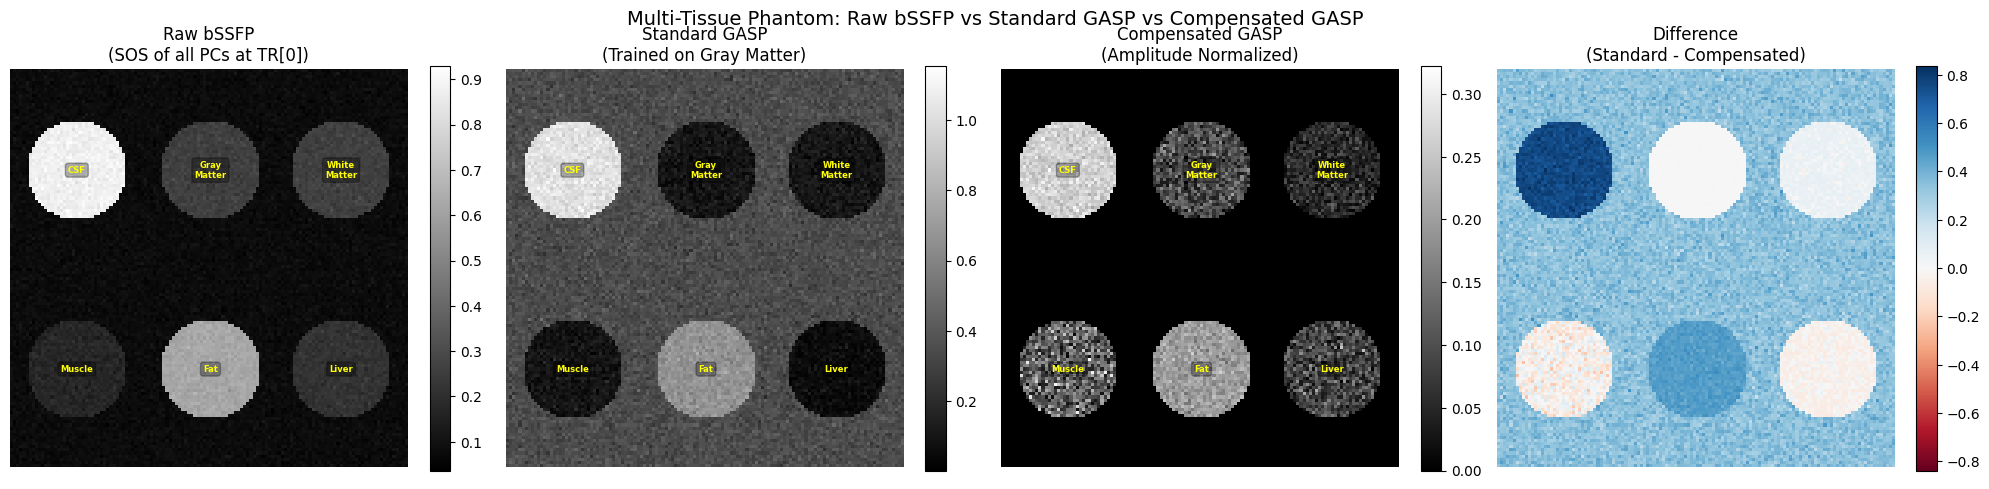

In [171]:
# Simulate bSSFP signals for the multi-tissue phantom
print("Simulating multi-tissue phantom signals...")

# Create phantom signals array: [H, W, n_acq]
phantom_signals = np.zeros((PHANTOM_SIZE, PHANTOM_SIZE, n_acq), dtype=complex)

# Simulate each tissue region
for idx, (name, props) in enumerate(PHANTOM_TISSUES.items()):
    mask = tissue_mask == (idx + 1)
    if not mask.any():
        continue
    
    # Simulate signal for this tissue (single representative voxel, then broadcast)
    T1, T2, M0 = props['T1'], props['T2'], props['M0']
    
    # Simulate on-resonance bSSFP signal
    sig = simulate_multi_tr(T1, T2, TRs, alpha, pcs, M0=M0)
    
    # Assign to all voxels in this tissue region
    phantom_signals[mask] = sig

# Add noise
phantom_signals_noisy = add_noise(phantom_signals, sigma=NOISE_SIGMA)

print(f"Phantom signals shape: {phantom_signals_noisy.shape}")
print(f"Noise level (sigma): {NOISE_SIGMA}")

# Train GASP on Gray Matter (the "training" tissue)
TRAIN_TISSUE = 'Gray Matter'
train_props = PHANTOM_TISSUES[TRAIN_TISSUE]
I_train_phantom = simulate_tissue(T1=train_props['T1'], T2=train_props['T2'])

# Use a simple passband profile for this demo
D_phantom = responses.bandpass(PHANTOM_SIZE, bw=0.3, shift=0)

# Train standard GASP
_, coeffs_std_phantom = train_gasp(I_train_phantom[:PHANTOM_SIZE, :], D_phantom, 
                                    method='affine', useL2=True, lam=1e-2)

# Train compensated GASP  
_, coeffs_comp_phantom, meta_phantom = train_compensated_gasp(
    I_train_phantom[:PHANTOM_SIZE, :], D_phantom, TRs, alpha, npcs, method='affine',
    known_t1=train_props['T1'], known_t2=train_props['T2'],
    useL2=True, lam=1e-2
)

print(f"\nGASP trained on: {TRAIN_TISSUE} (T2/T1={train_props['T2']/train_props['T1']:.3f})")

# Apply GASP to phantom
print("\nApplying GASP to phantom...")

# Standard GASP output - process whole phantom at once (already 3D: [H, W, n_acq])
out_std_phantom = np.abs(run_gasp(phantom_signals_noisy, coeffs_std_phantom, method='affine'))

# Compensated GASP output (need per-tissue compensation)
out_comp_phantom = np.zeros((PHANTOM_SIZE, PHANTOM_SIZE))
for idx, (name, props) in enumerate(PHANTOM_TISSUES.items()):
    mask = tissue_mask == (idx + 1)
    if not mask.any():
        continue
    
    # Get voxels for this tissue - reshape to [n_voxels, 1, n_acq] for run_compensated_gasp
    tissue_signals = phantom_signals_noisy[mask]  # [n_voxels, n_acq]
    # Add dummy height dimension to make it [n_voxels, 1, n_acq]
    tissue_signals_3d = tissue_signals[:, np.newaxis, :]
    
    # Apply compensated GASP with known T1/T2 for this tissue
    out_tissue = run_compensated_gasp(
        tissue_signals_3d, coeffs_comp_phantom, meta_phantom, method='affine',
        known_t1=props['T1'], known_t2=props['T2']
    )
    out_comp_phantom[mask] = np.abs(out_tissue).flatten()

# Compute raw bSSFP as Sum of Squares (SOS) across all phase cycles at TR[0]
# First npcs channels correspond to TR[0]
raw_bssfp = np.sqrt(np.sum(np.abs(phantom_signals_noisy[:, :, :npcs])**2, axis=-1))

print("GASP processing complete!")

# Display results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Raw bSSFP
im0 = axes[0].imshow(raw_bssfp, cmap='gray')
axes[0].set_title('Raw bSSFP\n(SOS of all PCs at TR[0])')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
axes[0].axis('off')

# Standard GASP
im1 = axes[1].imshow(out_std_phantom, cmap='gray')
axes[1].set_title(f'Standard GASP\n(Trained on {TRAIN_TISSUE})')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[1].axis('off')

# Compensated GASP
im2 = axes[2].imshow(out_comp_phantom, cmap='gray')
axes[2].set_title('Compensated GASP\n(Amplitude Normalized)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
axes[2].axis('off')

# Difference image
diff = out_std_phantom - out_comp_phantom
max_diff = np.abs(diff).max()
im3 = axes[3].imshow(diff, cmap='RdBu', vmin=-max_diff, vmax=max_diff)
axes[3].set_title('Difference\n(Standard - Compensated)')
plt.colorbar(im3, ax=axes[3], fraction=0.046)
axes[3].axis('off')

# Add tissue labels
for name, (cx, cy) in tissue_centers.items():
    for ax in axes[:3]:
        ax.text(cx, cy, name.replace(' ', '\n'), ha='center', va='center', 
                fontsize=6, color='yellow', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.3))

plt.suptitle('Multi-Tissue Phantom: Raw bSSFP vs Standard GASP vs Compensated GASP', fontsize=14)
plt.tight_layout()
plt.show()

SIGNAL-TO-NOISE RATIO (SNR) ANALYSIS

Training tissue: Gray Matter
Noise level: σ = 0.02

Tissue               Raw bSSFP       Standard GASP   Compensated GASP
----------------------------------------------------------------------
CSF                  43.15           21.77           13.47          
Gray Matter          13.45           2.35            2.39           
White Matter         13.75           2.42            1.98           
Muscle               8.87            2.34            2.09           
Fat                  31.48           14.96           8.74           
Liver                11.56           1.89            2.13           

CONTRAST-TO-NOISE RATIO (CNR) ANALYSIS

Tissue Pair                    Raw bSSFP    Standard     Compensated  Std vs Raw   Comp vs Std 
----------------------------------------------------------------------------------------------------
Gray Matter vs White Matter    0.08         0.07         0.86               -6.8%    +1043.8%
Gray Matter vs CSF     

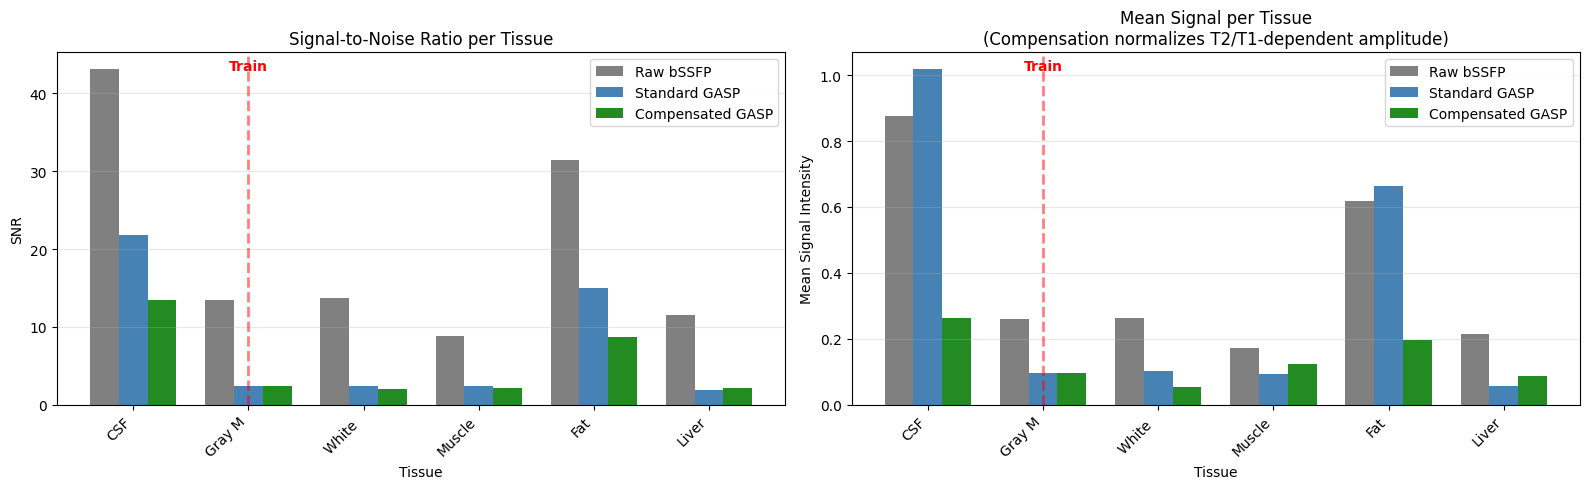


SUMMARY: TISSUE CONTRAST IMPLICATIONS

Mean SNR across all tissues:
  Raw bSSFP:        20.38
  Standard GASP:    7.62 (-62.6% vs Raw)
  Compensated GASP: 5.13 (-32.6% vs Standard)

Mean CNR across all tissue pairs:
  Raw bSSFP:        11.26
  Standard GASP:    7.18 (-36.2% vs Raw)
  Compensated GASP: 1.70 (-76.3% vs Standard)

----------------------------------------------------------------------------------------------------
KEY OBSERVATIONS:
----------------------------------------------------------------------------------------------------

1. STANDARD GASP preserves some T2/T1-based contrast because different tissues
   produce different spectral shapes that aren't perfectly matched by the
   coefficients trained on a single tissue.

2. COMPENSATED GASP reduces T2/T1-based amplitude differences, making tissues
   with different T2/T1 ratios appear more similar in signal intensity.

3. The REMAINING CONTRAST in compensated GASP comes from:
   - Proton density (M0) differences (NOT

In [172]:
# Calculate SNR and CNR for tissue analysis
def calculate_snr(image, mask):
    """
    Calculate Signal-to-Noise Ratio for a tissue region.
    SNR = mean(signal) / std(signal)
    """
    vals = image[mask]
    return vals.mean() / (vals.std() + 1e-10)

def calculate_cnr(image, mask1, mask2):
    """
    Calculate Contrast-to-Noise Ratio between two tissue regions.
    CNR = |mean(tissue1) - mean(tissue2)| / sqrt(var(tissue1) + var(tissue2))
    """
    vals1 = image[mask1]
    vals2 = image[mask2]
    
    mean1, mean2 = vals1.mean(), vals2.mean()
    var1, var2 = vals1.var(), vals2.var()
    
    contrast = np.abs(mean1 - mean2)
    noise = np.sqrt(var1 + var2)
    
    cnr = contrast / (noise + 1e-10)
    return cnr, mean1, mean2, np.sqrt(var1), np.sqrt(var2)

# Get tissue masks
tissue_masks = {}
tissue_names = list(PHANTOM_TISSUES.keys())
for idx, name in enumerate(tissue_names):
    tissue_masks[name] = tissue_mask == (idx + 1)

# Calculate SNR for each tissue
print("=" * 100)
print("SIGNAL-TO-NOISE RATIO (SNR) ANALYSIS")
print("=" * 100)
print(f"\nTraining tissue: {TRAIN_TISSUE}")
print(f"Noise level: σ = {NOISE_SIGMA}")
print()

results_snr = []
for name in tissue_names:
    mask = tissue_masks[name]
    
    snr_raw = calculate_snr(raw_bssfp, mask)
    snr_std = calculate_snr(out_std_phantom, mask)
    snr_comp = calculate_snr(out_comp_phantom, mask)
    
    results_snr.append({
        'tissue': name,
        'snr_raw': snr_raw,
        'snr_std': snr_std,
        'snr_comp': snr_comp,
    })

# Print SNR table
print(f"{'Tissue':<20} {'Raw bSSFP':<15} {'Standard GASP':<15} {'Compensated GASP':<15}")
print("-" * 70)
for r in results_snr:
    print(f"{r['tissue']:<20} {r['snr_raw']:<15.2f} {r['snr_std']:<15.2f} {r['snr_comp']:<15.2f}")
print("=" * 100)

# Calculate CNR for clinically relevant tissue pairs
tissue_pairs = [
    ('Gray Matter', 'White Matter'),   # Brain GM/WM contrast
    ('Gray Matter', 'CSF'),            # Brain GM/CSF contrast
    ('Muscle', 'Fat'),                 # Musculoskeletal contrast
    ('Liver', 'Fat'),                  # Abdominal contrast
    ('Gray Matter', 'Muscle'),         # Cross-organ contrast
]

print("\n" + "=" * 100)
print("CONTRAST-TO-NOISE RATIO (CNR) ANALYSIS")
print("=" * 100)

results_cnr = []
for tissue1, tissue2 in tissue_pairs:
    mask1 = tissue_masks[tissue1]
    mask2 = tissue_masks[tissue2]
    
    cnr_raw, m1_raw, m2_raw, s1_raw, s2_raw = calculate_cnr(raw_bssfp, mask1, mask2)
    cnr_std, m1_std, m2_std, s1_std, s2_std = calculate_cnr(out_std_phantom, mask1, mask2)
    cnr_comp, m1_comp, m2_comp, s1_comp, s2_comp = calculate_cnr(out_comp_phantom, mask1, mask2)
    
    results_cnr.append({
        'pair': f'{tissue1} vs {tissue2}',
        'cnr_raw': cnr_raw,
        'cnr_std': cnr_std,
        'cnr_comp': cnr_comp,
        'change_std_vs_raw': (cnr_std - cnr_raw) / cnr_raw * 100,
        'change_comp_vs_std': (cnr_comp - cnr_std) / cnr_std * 100 if cnr_std > 0 else 0,
    })

# Print CNR table
print(f"\n{'Tissue Pair':<30} {'Raw bSSFP':<12} {'Standard':<12} {'Compensated':<12} {'Std vs Raw':<12} {'Comp vs Std':<12}")
print("-" * 100)
for r in results_cnr:
    print(f"{r['pair']:<30} {r['cnr_raw']:<12.2f} {r['cnr_std']:<12.2f} {r['cnr_comp']:<12.2f} "
          f"{r['change_std_vs_raw']:>+10.1f}% {r['change_comp_vs_std']:>+10.1f}%")
print("=" * 100)

# Plot SNR and Mean Signal comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of SNR values per tissue
x = np.arange(len(tissue_names))
width = 0.25

snr_raw_vals = [r['snr_raw'] for r in results_snr]
snr_std_vals = [r['snr_std'] for r in results_snr]
snr_comp_vals = [r['snr_comp'] for r in results_snr]

bars1 = axes[0].bar(x - width, snr_raw_vals, width, label='Raw bSSFP', color='gray')
bars2 = axes[0].bar(x, snr_std_vals, width, label='Standard GASP', color='steelblue')
bars3 = axes[0].bar(x + width, snr_comp_vals, width, label='Compensated GASP', color='forestgreen')

axes[0].set_xlabel('Tissue')
axes[0].set_ylabel('SNR')
axes[0].set_title('Signal-to-Noise Ratio per Tissue')
axes[0].set_xticks(x)
axes[0].set_xticklabels([name[:6] for name in tissue_names], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Mark training tissue
train_idx = tissue_names.index(TRAIN_TISSUE)
axes[0].axvline(train_idx, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[0].text(train_idx, axes[0].get_ylim()[1] * 0.95, 'Train', ha='center', color='red', fontweight='bold')

# Mean signal per tissue
tissue_means_raw = [raw_bssfp[tissue_masks[name]].mean() for name in tissue_names]
tissue_means_std = [out_std_phantom[tissue_masks[name]].mean() for name in tissue_names]
tissue_means_comp = [out_comp_phantom[tissue_masks[name]].mean() for name in tissue_names]

bars4 = axes[1].bar(x - width, tissue_means_raw, width, label='Raw bSSFP', color='gray')
bars5 = axes[1].bar(x, tissue_means_std, width, label='Standard GASP', color='steelblue')
bars6 = axes[1].bar(x + width, tissue_means_comp, width, label='Compensated GASP', color='forestgreen')

axes[1].set_xlabel('Tissue')
axes[1].set_ylabel('Mean Signal Intensity')
axes[1].set_title('Mean Signal per Tissue\n(Compensation normalizes T2/T1-dependent amplitude)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([name[:6] for name in tissue_names], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Mark training tissue
axes[1].axvline(train_idx, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[1].text(train_idx, axes[1].get_ylim()[1] * 0.95, 'Train', ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 100)
print("SUMMARY: TISSUE CONTRAST IMPLICATIONS")
print("=" * 100)

mean_snr_raw = np.mean(snr_raw_vals)
mean_snr_std = np.mean(snr_std_vals)
mean_snr_comp = np.mean(snr_comp_vals)

print(f"\nMean SNR across all tissues:")
print(f"  Raw bSSFP:        {mean_snr_raw:.2f}")
print(f"  Standard GASP:    {mean_snr_std:.2f} ({(mean_snr_std-mean_snr_raw)/mean_snr_raw*100:+.1f}% vs Raw)")
print(f"  Compensated GASP: {mean_snr_comp:.2f} ({(mean_snr_comp-mean_snr_std)/mean_snr_std*100:+.1f}% vs Standard)")

mean_cnr_raw = np.mean([r['cnr_raw'] for r in results_cnr])
mean_cnr_std = np.mean([r['cnr_std'] for r in results_cnr])
mean_cnr_comp = np.mean([r['cnr_comp'] for r in results_cnr])

print(f"\nMean CNR across all tissue pairs:")
print(f"  Raw bSSFP:        {mean_cnr_raw:.2f}")
print(f"  Standard GASP:    {mean_cnr_std:.2f} ({(mean_cnr_std-mean_cnr_raw)/mean_cnr_raw*100:+.1f}% vs Raw)")
print(f"  Compensated GASP: {mean_cnr_comp:.2f} ({(mean_cnr_comp-mean_cnr_std)/mean_cnr_std*100:+.1f}% vs Standard)")

print("\n" + "-" * 100)
print("KEY OBSERVATIONS:")
print("-" * 100)
print("""
1. STANDARD GASP preserves some T2/T1-based contrast because different tissues
   produce different spectral shapes that aren't perfectly matched by the
   coefficients trained on a single tissue.

2. COMPENSATED GASP reduces T2/T1-based amplitude differences, making tissues
   with different T2/T1 ratios appear more similar in signal intensity.

3. The REMAINING CONTRAST in compensated GASP comes from:
   - Proton density (M0) differences (NOT normalized)
   - How well the spectral profile matches each tissue's frequency content
   - Residual spectral shape differences

4. TRADE-OFF:
   - Standard GASP: Better tissue contrast, but less accurate spectral shaping
   - Compensated GASP: More uniform spectral response, but reduced T2/T1 contrast
""")
print("=" * 100)